Saving group-coursework-refdef-data-files.zip to group-coursework-refdef-data-files.zip
Extracted group-coursework-refdef-data-files.zip contents.
Files loaded. Shapes:
  contrib_total: (41724, 4)
  contrib_gas: (41724, 6)
  ghg_region: (37496, 4)
  fossil: (41724, 4)
  land: (38988, 4)
  anomaly: (522, 6)
Anomaly file entities: ['Global' 'Northern hemisphere' 'Southern hemisphere']

Missing values per dataset:

contrib_total:
Entity                   0
Code                  4446
Year                     0
temp_contrib_total       0
dtype: int64

contrib_gas:
Entity                 0
Code                4446
Year                   0
temp_contrib_n2o    4104
temp_contrib_ch4    4104
temp_contrib_co2       0
dtype: int64

ghg_region:
Entity                    0
Code                   3096
Year                      0
ghg_emissions_co2eq       0
dtype: int64

fossil:
Entity                    0
Code                   4446
Year                      0
temp_contrib_fossil       0
dtype: int64

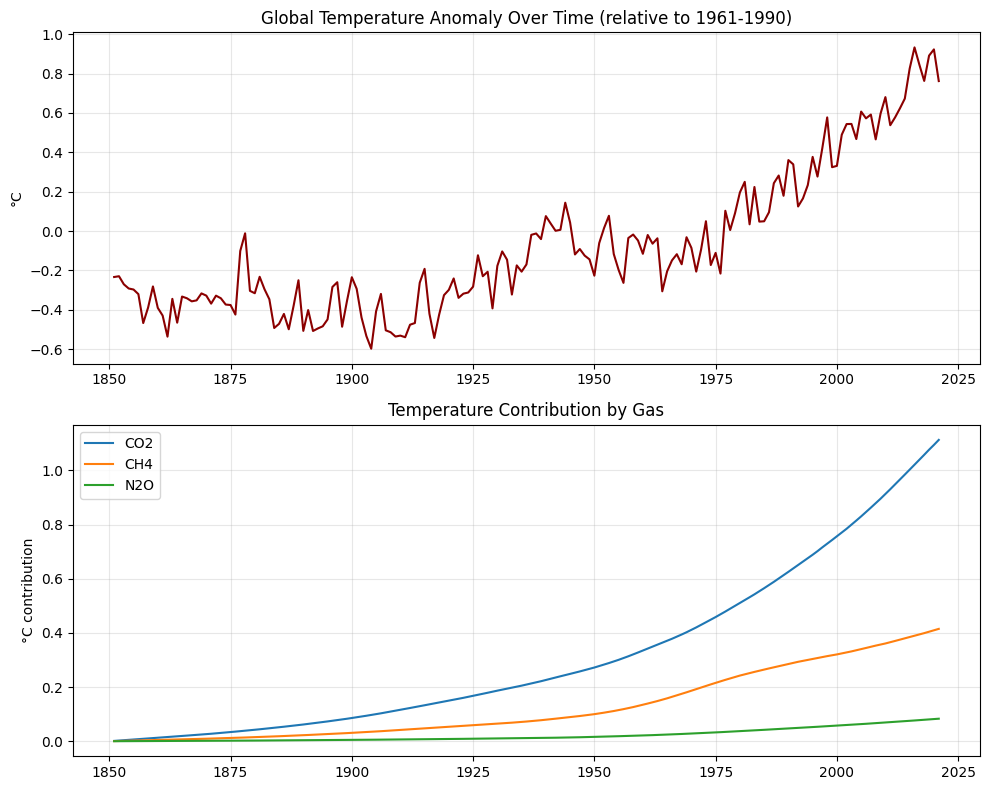

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# Upload files and import libraries

#Upload files
from google.colab import files
uploaded = files.upload()  # select all 6 files

# Unzip the uploaded file if it's a zip file
import zipfile
import os

for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')  # Extract all contents to the current directory
        print(f"Extracted {filename} contents.")

#Load and inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the datasets
contrib_total = pd.read_csv('contribution-temp-rise-degrees.csv')
contrib_gas   = pd.read_csv('contribution-to-temp-rise-by-gas.csv')
ghg_region    = pd.read_excel('ghg-emissions-by-world-region.xlsx')
fossil        = pd.read_excel('global-warming-fossil.xlsx')
land          = pd.read_excel('global-warming-land.xlsx')
anomaly       = pd.read_csv('temperature-anomaly.csv')

print("Files loaded. Shapes:")
for name, df in [('contrib_total', contrib_total), ('contrib_gas', contrib_gas),
                  ('ghg_region', ghg_region), ('fossil', fossil),
                  ('land', land), ('anomaly', anomaly)]:
    print(f"  {name}: {df.shape}")


# Clean and prepare the data
contrib_total = contrib_total.rename(columns={contrib_total.columns[3]: 'temp_contrib_total'})
contrib_gas = contrib_gas.rename(columns={
    contrib_gas.columns[3]: 'temp_contrib_n2o',
    contrib_gas.columns[4]: 'temp_contrib_ch4',
    contrib_gas.columns[5]: 'temp_contrib_co2'
})
ghg_region = ghg_region.rename(columns={ghg_region.columns[3]: 'ghg_emissions_co2eq'})
fossil = fossil.rename(columns={fossil.columns[3]: 'temp_contrib_fossil'})
land = land.rename(columns={land.columns[3]: 'temp_contrib_land'})
anomaly = anomaly.rename(columns={
    anomaly.columns[3]: 'temp_anomaly',
    anomaly.columns[4]: 'temp_anomaly_upper',
    anomaly.columns[5]: 'temp_anomaly_lower'
})

# Data quality check
print("Anomaly file entities:", anomaly['Entity'].unique())
print("\nMissing values per dataset:")
for name, df in [('contrib_total', contrib_total), ('contrib_gas', contrib_gas),
                  ('ghg_region', ghg_region), ('fossil', fossil), ('land', land)]:
    print(f"\n{name}:\n{df.isnull().sum()}")


# # Merge datasets
panel = contrib_total[['Entity','Code','Year','temp_contrib_total']]
for df, cols in [(contrib_gas, ['temp_contrib_n2o','temp_contrib_ch4','temp_contrib_co2']),
                  (ghg_region, ['ghg_emissions_co2eq']),
                  (fossil, ['temp_contrib_fossil']),
                  (land, ['temp_contrib_land'])]:
    panel = panel.merge(df[['Entity','Year'] + cols], on=['Entity','Year'], how='left')

print("Panel shape:", panel.shape)

# Handle missing values: forward-fill within each Entity's time series,
panel = panel.sort_values(['Entity','Year'])
value_cols = ['temp_contrib_n2o','temp_contrib_ch4','ghg_emissions_co2eq','temp_contrib_land']
panel[value_cols] = panel.groupby('Entity')[value_cols].transform(lambda x: x.ffill().bfill())

# Drop rows that are still missing
panel_clean = panel.dropna(subset=value_cols)
print("Cleaned panel shape:", panel_clean.shape)


# # Create global time series
world = panel_clean[panel_clean['Entity']=='World'].copy()
global_anomaly = anomaly[anomaly['Entity']=='Global'][['Year','temp_anomaly']]
global_ts = world.merge(global_anomaly, on='Year', how='inner').sort_values('Year').reset_index(drop=True)

print("Global time series:", global_ts.shape)
global_ts.head()


# # Exploratory data analysis
fig, axes = plt.subplots(2, 1, figsize=(10,8))
axes[0].plot(global_ts['Year'], global_ts['temp_anomaly'], color='darkred')
axes[0].set_title('Global Temperature Anomaly Over Time (relative to 1961-1990)')
axes[0].set_ylabel('°C')
axes[0].grid(alpha=0.3)

axes[1].plot(global_ts['Year'], global_ts['temp_contrib_co2'], label='CO2')
axes[1].plot(global_ts['Year'], global_ts['temp_contrib_ch4'], label='CH4')
axes[1].plot(global_ts['Year'], global_ts['temp_contrib_n2o'], label='N2O')
axes[1].set_title('Temperature Contribution by Gas')
axes[1].set_ylabel('°C contribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_trends.png', dpi=150)
plt.show()


# # Save cleaned datasets
panel_clean.to_csv('cleaned_country_panel.csv', index=False)
global_ts.to_csv('cleaned_global_timeseries.csv', index=False)
files.download('cleaned_country_panel.csv')
files.download('cleaned_global_timeseries.csv')

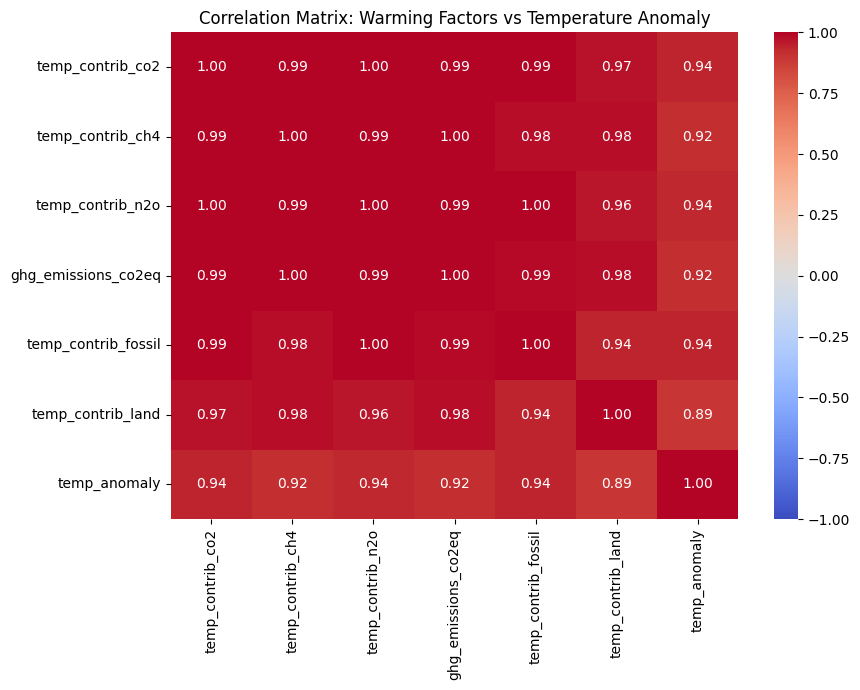

In [2]:
# Correlation analysis
!pip install statsmodels -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

global_ts = pd.read_csv('cleaned_global_timeseries.csv')  # or re-load from Step 1 output

features = ['temp_contrib_co2','temp_contrib_ch4','temp_contrib_n2o',
            'ghg_emissions_co2eq','temp_contrib_fossil','temp_contrib_land']

corr_matrix = global_ts[features + ['temp_anomaly']].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Warming Factors vs Temperature Anomaly')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


In [3]:
# Multicollinearity (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = global_ts[features].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
print(vif_data.sort_values('VIF', ascending=False))

               feature           VIF
0     temp_contrib_co2  9.293447e+09
4  temp_contrib_fossil  2.008421e+09
5    temp_contrib_land  1.183485e+09
1     temp_contrib_ch4  1.069939e+09
2     temp_contrib_n2o  7.390639e+06
3  ghg_emissions_co2eq  2.198624e+02


In [4]:
# Select features after VIF analysis

selected_features = ['temp_contrib_co2', 'ghg_emissions_co2eq']

X_selected = global_ts[selected_features].dropna()
vif_selected = pd.DataFrame()
vif_selected['feature'] = selected_features
vif_selected['VIF'] = [variance_inflation_factor(X_selected.values, i) for i in range(len(selected_features))]
print("\nVIF after feature selection:")
print(vif_selected)


VIF after feature selection:
               feature        VIF
0     temp_contrib_co2  68.927189
1  ghg_emissions_co2eq  68.927189


In [5]:

# Train and test regression models
# Linear Regression, Ridge Regression and Lasso Regression

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Sort data chronologically

global_ts = global_ts.sort_values("Year")


# Train-Test Split


train = global_ts[global_ts["Year"] <= 1990]
test = global_ts[global_ts["Year"] > 1990]

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)
print(f"Training Years : {train['Year'].min()} - {train['Year'].max()}")
print(f"Testing Years  : {test['Year'].min()} - {test['Year'].max()}")
print(f"Training Samples : {len(train)}")
print(f"Testing Samples  : {len(test)}")


# Predictor Variables


features = ["temp_contrib_co2", "Year"]

X_train = train[features]
y_train = train["temp_anomaly"]

X_test = test[features]
y_test = test["temp_anomaly"]

TRAIN TEST SPLIT
Training Years : 1851 - 1990
Testing Years  : 1991 - 2021
Training Samples : 140
Testing Samples  : 31


In [6]:

# Ordinary Least Squares (OLS)

ols = LinearRegression()

# Train the model
ols.fit(X_train, y_train)

# Make predictions
ols_pred = ols.predict(X_test)

# Evaluate the model
ols_r2 = r2_score(y_test, ols_pred)
ols_mae = mean_absolute_error(y_test, ols_pred)
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))

In [7]:

# Ridge Regression

ridge = RidgeCV(alphas=[0.01,0.1,1,10,100])

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

In [8]:

# Lasso Regression

lasso = LassoCV(
    alphas=[0.001,0.01,0.1,1],
    cv=5,
    random_state=42
)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

In [9]:
# Compare model performance


results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "R²":[
        ols_r2,
        ridge_r2,
        lasso_r2
    ],

    "MAE":[
        ols_mae,
        ridge_mae,
        lasso_mae
    ],

    "RMSE":[
        ols_rmse,
        ridge_rmse,
        lasso_rmse
    ]

})

results = results.sort_values("R²", ascending=False)

print("\n")
print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

display(results)

results.to_csv("model_performance.csv", index=False)



MODEL PERFORMANCE COMPARISON


,Model,R²,MAE,RMSE
0,Linear Regression,0.741520,0.091154,0.108515
1,Ridge Regression,0.707108,0.095938,0.115513
2,Lasso Regression,-5.424759,0.507138,0.541010


In [10]:
# Select Best Model
best_model_name = results.iloc[0]["Model"]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Champion Model : {best_model_name}")

if best_model_name == "Linear Regression":
    final_model = ols

elif best_model_name == "Ridge Regression":
    final_model = ridge

else:
    final_model = lasso



BEST MODEL
Champion Model : Linear Regression


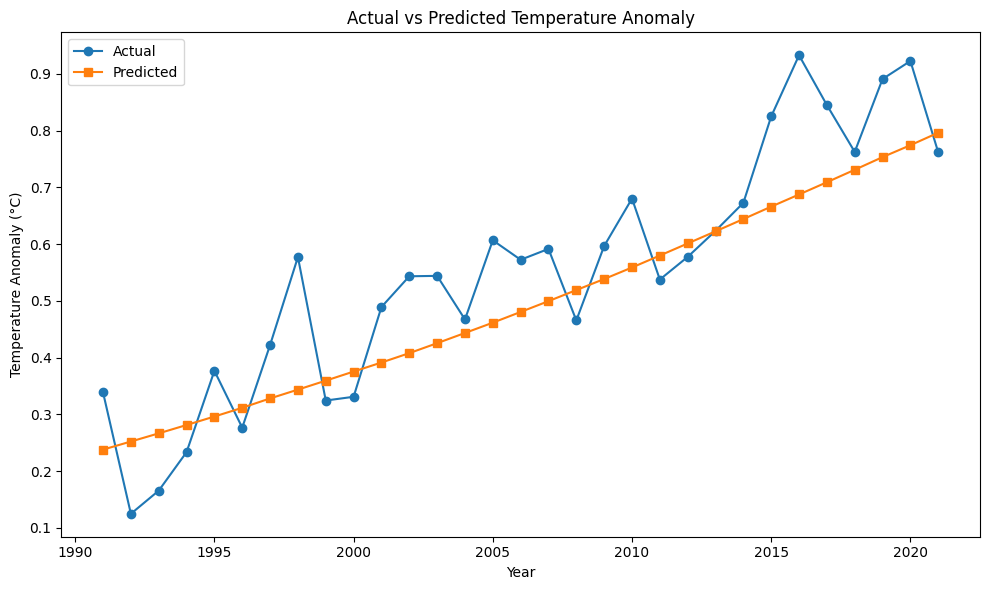

In [11]:
# Actual vs predicted values

if best_model_name == "Linear Regression":
    predictions = ols_pred

elif best_model_name == "Ridge Regression":
    predictions = ridge_pred

else:
    predictions = lasso_pred

plt.figure(figsize=(10,6))

plt.plot(
    test["Year"],
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test["Year"],
    predictions,
    marker="s",
    label="Predicted"
)

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Actual vs Predicted Temperature Anomaly")

plt.legend()

plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

   Year  Projected_CO2_contrib  Projected_temp_anomaly
0  2022                  1.049                   0.788
1  2023                  1.063                   0.806
2  2024                  1.077                   0.824
3  2025                  1.091                   0.842
4  2026                  1.105                   0.861
5  2027                  1.120                   0.879
6  2028                  1.134                   0.898
7  2029                  1.149                   0.917
8  2030                  1.164                   0.936
9  2031                  1.178                   0.955


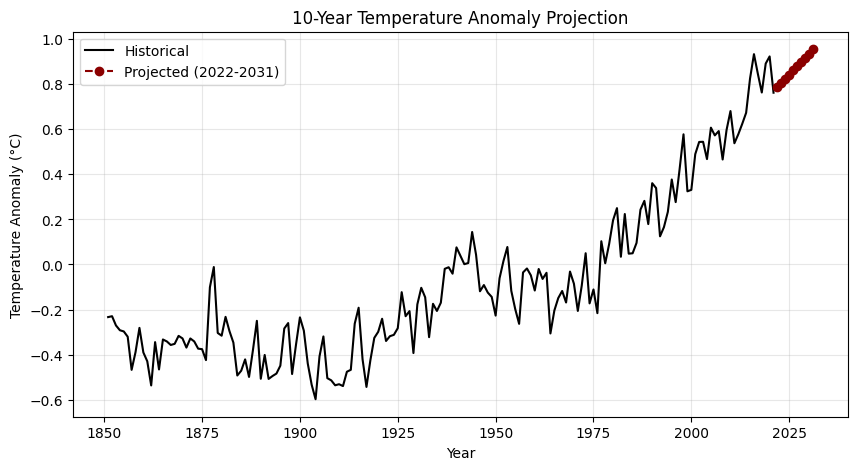

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Forecast future temperature anomaly

# Refit on ALL available data for the final forward-looking projection
final_model = LinearRegression()
final_model.fit(global_ts[features], global_ts['temp_anomaly'])

# Project CO2 contribution forward using a quadratic trend (captures acceleration)
co2_trend_coefs = np.polyfit(global_ts['Year'], global_ts['temp_contrib_co2'], 2)
future_years = np.arange(2022, 2032)
future_co2 = np.polyval(co2_trend_coefs, future_years)

future_X = pd.DataFrame({'temp_contrib_co2': future_co2, 'Year': future_years})
future_preds = final_model.predict(future_X)

projection = pd.DataFrame({'Year': future_years, 'Projected_CO2_contrib': future_co2.round(3),
                            'Projected_temp_anomaly': future_preds.round(3)})
print(projection)

plt.figure(figsize=(10,5))
plt.plot(global_ts['Year'], global_ts['temp_anomaly'], label='Historical', color='black')
plt.plot(future_years, future_preds, label='Projected (2022-2031)', color='darkred', linestyle='--', marker='o')
plt.title('10-Year Temperature Anomaly Projection')
plt.xlabel('Year'); plt.ylabel('Temperature Anomaly (°C)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('projection_10yr.png', dpi=150)
plt.show()

projection.to_csv('10yr_projection.csv', index=False)
files.download('10yr_projection.csv')

In [13]:
# Regional risk analysis

panel_clean = pd.read_csv('cleaned_country_panel.csv')  # from Step 1 output

# Filter out aggregate income-group entities, keep countries + continents + World
exclude = ['World', 'High-income countries', 'Low-income countries',
           'Upper-middle-income countries', 'Lower-middle-income countries',
           'Least developed countries (Jones et al. 2023)', 'OECD (Jones et al. 2023)']

latest_year = panel_clean['Year'].max()
recent = panel_clean[(panel_clean['Year'] == latest_year) & (~panel_clean['Entity'].isin(exclude))]

# Rank by total temperature contribution (most recent year available)
top_contributors = recent.sort_values('temp_contrib_total', ascending=False).head(15)
print(f"Top 15 contributors to warming, {latest_year}:")
print(top_contributors[['Entity','temp_contrib_total','temp_contrib_co2','ghg_emissions_co2eq']])

# Rank by RATE OF CHANGE (1990-2021) - this is more actuarially relevant:
# which regions are accelerating fastest, not just who's currently highest
early = panel_clean[(panel_clean['Year']==1990) & (~panel_clean['Entity'].isin(exclude))][['Entity','temp_contrib_total']].rename(columns={'temp_contrib_total':'contrib_1990'})
late = panel_clean[(panel_clean['Year']==latest_year) & (~panel_clean['Entity'].isin(exclude))][['Entity','temp_contrib_total']].rename(columns={'temp_contrib_total':'contrib_latest'})
change = early.merge(late, on='Entity')
change['pct_change'] = ((change['contrib_latest'] - change['contrib_1990']) / change['contrib_1990']) * 100
top_accelerating = change.sort_values('pct_change', ascending=False).head(15)
print(f"\nFastest-accelerating contributors, 1990-{latest_year}:")
print(top_accelerating)

Top 15 contributors to warming, 2021:
                             Entity  temp_contrib_total  temp_contrib_co2  \
1880                           Asia            0.574748          0.353852   
24623                 North America            0.352048          0.284156   
11285                        Europe            0.340648          0.268130   
2051   Asia (excl. China and India)            0.299250          0.189614   
35567                 United States            0.279196          0.232595   
11969           European Union (28)            0.205695          0.165856   
7010                          China            0.198681          0.127758   
11456          Europe (excl. EU-27)            0.173783          0.136305   
11798           European Union (27)            0.166865          0.131824   
341                          Africa            0.147950          0.077054   
31121                 South America            0.144665          0.092301   
11627          Europe (excl. EU-28)   

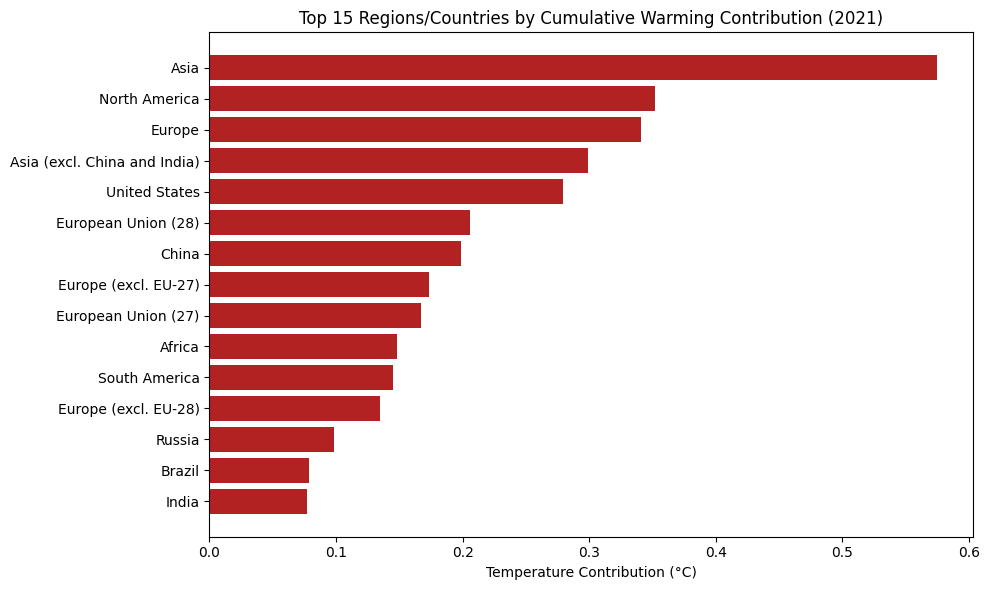

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Visualise regional risk

plt.figure(figsize=(10,6))
plt.barh(top_contributors['Entity'][::-1], top_contributors['temp_contrib_total'][::-1], color='firebrick')
plt.xlabel('Temperature Contribution (°C)')
plt.title(f'Top 15 Regions/Countries by Cumulative Warming Contribution ({latest_year})')
plt.tight_layout()
plt.savefig('top_contributors.png', dpi=150)
plt.show()

top_contributors.to_csv('top_contributors.csv', index=False)
top_accelerating.to_csv('top_accelerating.csv', index=False)
files.download('top_contributors.csv')
files.download('top_accelerating.csv')

In [15]:
# Filter regions with meaningful warming contributions

threshold = early['contrib_1990'].quantile(0.75)  # top quartile by 1990 baseline
change_filtered = change[change['contrib_1990'] >= threshold]
top_accelerating_filtered = change_filtered.sort_values('pct_change', ascending=False).head(15)
print("Fastest-accelerating MEANINGFUL contributors (1990 baseline in top quartile):")
print(top_accelerating_filtered)

Fastest-accelerating MEANINGFUL contributors (1990 baseline in top quartile):
                           Entity  contrib_1990  contrib_latest  pct_change
40                          China      0.066546        0.198681  198.559847
146                      Pakistan      0.004714        0.012163  158.005453
91                           Iran      0.007257        0.018554  155.682510
194                        Turkey      0.004265        0.010434  144.654409
116                      Malaysia      0.004184        0.009912  136.928650
51   Democratic Republic of Congo      0.004845        0.010989  126.802805
10                           Asia      0.254195        0.574748  126.105153
207                       Vietnam      0.005211        0.010842  108.048560
90                      Indonesia      0.026830        0.055397  106.476270
11   Asia (excl. China and India)      0.148052        0.299250  102.125465
175                  South Africa      0.008548        0.016605   94.263270
89        